Import Libraries And Load The Clean Dataset

In [4]:
import pandas as pd
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../notebooks/mental_health_dataset_cleaned.csv')
df.head()


,Unique_ID,text,status,clean_text
0,0.0,oh my gosh,Anxiety,oh gosh
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleep confuse mind restless heart tune
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,wrong back dear forward doubt stay restless re...
3,3.0,I've shifted my focus to something else but I'...,Anxiety,ive shift focus something else im still worry
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety,im restless restless month boy mean


Drop NaNs from clean_text

In [5]:
df = df.dropna(subset=['clean_text'])
print(df['clean_text'].isnull().sum())  

0


Splitting the dataset into 80% training and 20% testing data, then configuring TF-IDF to convert cleaned text into numerical features while filtering out rare and common words.

In [6]:
X = df['clean_text']
y = df['status'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.9,
    max_features=15000
)

Learn All Unique Words And Convert Training Text To Number

In [7]:
X_train_tfidf = vectorizer.fit_transform(X_train)

Transform Testing Text to Number. Note - No learning, just transform

In [8]:
X_test_tfidf = vectorizer.transform(X_test)

Check Shape

In [9]:
X_train_tfidf.shape

(39623, 8728)

Show Some Feature Names

In [10]:
print(vectorizer.get_feature_names_out()[:50])

['ab' 'abandon' 'abandonment' 'abd' 'abdomen' 'abdominal' 'abilify'
 'abilities' 'ability' 'abit' 'able' 'abnormal' 'abnormally' 'abort'
 'abortion' 'abouti' 'abroad' 'abrupt' 'abruptly' 'abs' 'absence' 'absent'
 'absolute' 'absolutely' 'absorb' 'absurd' 'abt' 'abuse' 'abuser'
 'abusers' 'abusive' 'abyss' 'ac' 'academic' 'academically' 'academics'
 'acc' 'accelerate' 'accent' 'accept' 'acceptable' 'acceptance' 'access'
 'accessible' 'accessories' 'accident' 'accidental' 'accidentally'
 'accidents' 'accommodate']


Show the actual numbers generated for each word:

In [11]:
df_tfidf = pd.DataFrame(X_train_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
print(df_tfidf.head())

    ab  abandon  abandonment  abd  abdomen  abdominal  abilify  abilities  \
0  0.0      0.0          0.0  0.0      0.0        0.0      0.0        0.0   
1  0.0      0.0          0.0  0.0      0.0        0.0      0.0        0.0   
2  0.0      0.0          0.0  0.0      0.0        0.0      0.0        0.0   
3  0.0      0.0          0.0  0.0      0.0        0.0      0.0        0.0   
4  0.0      0.0          0.0  0.0      0.0        0.0      0.0        0.0   

   ability  abit  ...  zero  zip  zoloft  zombie  zombies  zonaba  zonauang  \
0      0.0   0.0  ...   0.0  0.0     0.0     0.0      0.0     0.0       0.0   
1      0.0   0.0  ...   0.0  0.0     0.0     0.0      0.0     0.0       0.0   
2      0.0   0.0  ...   0.0  0.0     0.0     0.0      0.0     0.0       0.0   
3      0.0   0.0  ...   0.0  0.0     0.0     0.0      0.0     0.0       0.0   
4      0.0   0.0  ...   0.0  0.0     0.0     0.0      0.0     0.0       0.0   

   zone  zoo  zoom  
0   0.0  0.0   0.0  
1   0.0  0.0   0.0  

See non-zero words for first post

In [12]:
row = df_tfidf.iloc[0]
print(row[row > 0])

alone       0.193828
anyone      0.161388
come        0.169490
company     0.310436
cough       0.712575
keep        0.172475
na          0.228253
saturday    0.355667
wan         0.265304
work        0.157452
Name: 0, dtype: float64


 RANDOM FOREST(training model)

In [13]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
rf_pred = rf_model.predict(X_test_tfidf)

SVM(Support Vector Machine) training model

In [14]:
svm_model = LinearSVC(max_iter=1000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)
svm_predictions = svm_model.predict(X_test_tfidf)

In [19]:
def predict_status(text):
    vectorized = vectorizer.transform([text])
    prediction = rf_model.predict(vectorized)
    return prediction[0]

# Test it
user_input = input("Enter a post: ")
print("Predicted Status:", predict_status(user_input))

Predicted Status: Normal


Import libraries needed for Evaluation

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# ======= CLASSIFICATION REPORT =======
print("RANDOM FOREST REPORT")
print(classification_report(y_test, rf_pred))

RANDOM FOREST REPORT
              precision    recall  f1-score   support

     Anxiety       0.91      0.58      0.71      1101
  Depression       0.63      0.74      0.68      2901
      Normal       0.84      0.93      0.88      3663
    Suicidal       0.69      0.52      0.59      2241

    accuracy                           0.74      9906
   macro avg       0.77      0.69      0.72      9906
weighted avg       0.75      0.74      0.74      9906



In [24]:
print("SVM REPORT")
print(classification_report(y_test, svm_predictions))

SVM REPORT
              precision    recall  f1-score   support

     Anxiety       0.83      0.75      0.79      1101
  Depression       0.71      0.66      0.68      2901
      Normal       0.85      0.95      0.90      3663
    Suicidal       0.66      0.62      0.64      2241

    accuracy                           0.77      9906
   macro avg       0.76      0.75      0.75      9906
weighted avg       0.76      0.77      0.76      9906



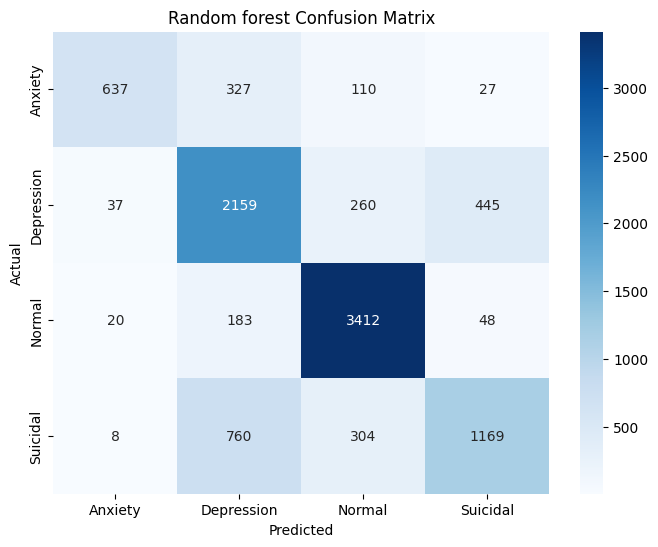

In [26]:
# ======= CONFUSION MATRIX - RANDOM FOREST =======
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, rf_pred), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Anxiety','Depression','Normal','Suicidal'],
            yticklabels=['Anxiety','Depression','Normal','Suicidal'])
plt.title('Random forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

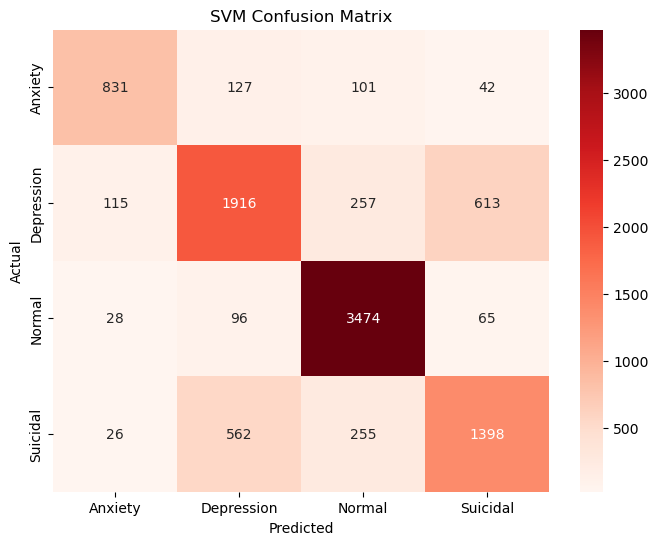

In [ ]:
# ======= CONFUSION MATRIX - SVM =======
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, svm_predictions), 
            annot=True, fmt='d', cmap='Reds',
            xticklabels=['Anxiety','Depression','Normal','Suicidal'],
            yticklabels=['Anxiety','Depression','Normal','Suicidal'])
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Models saved successfully ✅


In [ ]:
import joblib

joblib.dump(rf_model, '../models/rf_model.pkl')
joblib.dump(svm_model, '../models/svm_model.pkl')
joblib.dump(vectorizer, '../models/vectorizer.pkl')

print("Models saved successfully ✅")